In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt

sub = "sub-P10"
ses = "ses-05"

events_file = Path("data/preprocessed/relabeled_events") / f"{sub}_{ses}_task-viewing_run-01_events_memory_labels.tsv"
func_dir = Path("data/fmriprep_output") / sub / ses / "func"
confounds_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_desc-confounds_timeseries.tsv"
bold_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
meta_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.json"

events = pd.read_csv(events_file, sep="\t")
confounds = pd.read_csv(confounds_file, sep="\t")
bold_img = nib.load(str(bold_file))

print("Events:", events.shape)
print("Confounds:", confounds.shape)
print("BOLD:", bold_img.shape)
print(events["trial_type_memory"].value_counts())
events.head()

Events: (384, 9)
Confounds: (1994, 851)
BOLD: (62, 77, 66, 1994)
trial_type_memory
other                               312
irrelevant_seen_schema_week          30
irrelevant_seen_other_wrong_week     24
irrelevant_seen_true_week            18
Name: count, dtype: int64


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time,memory_label,trial_type_memory
0,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,0.922,NaN,other
1,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.597,other_wrong_week,irrelevant_seen_other_wrong_week
2,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.490,NaN,other
3,23.599,3.016,viking_11_new.jpg,1,2.0,Right,0.452,NaN,other
4,29.499,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.391,other_wrong_week,irrelevant_seen_other_wrong_week


In [2]:
# Minimal events table for Nilearn
glm_events = events[["onset", "duration", "trial_type_memory"]].copy()
glm_events = glm_events.rename(columns={"trial_type_memory": "trial_type"})

# Optional: remove "other" if you do not want to model it explicitly
# For now keep it, so all task events are modeled.
print(glm_events["trial_type"].value_counts())

glm_events.head()

trial_type
other                               312
irrelevant_seen_schema_week          30
irrelevant_seen_other_wrong_week     24
irrelevant_seen_true_week            18
Name: count, dtype: int64


,onset,duration,trial_type
0,4.632,3.034,other
1,10.815,3.017,irrelevant_seen_other_wrong_week
2,17.065,3.017,other
3,23.599,3.016,other
4,29.499,3.016,irrelevant_seen_other_wrong_week


Design matrix shape: (1994, 73)
['irrelevant_seen_other_wrong_week', 'irrelevant_seen_other_wrong_week_derivative', 'irrelevant_seen_other_wrong_week_dispersion', 'irrelevant_seen_schema_week', 'irrelevant_seen_schema_week_derivative', 'irrelevant_seen_schema_week_dispersion', 'irrelevant_seen_true_week', 'irrelevant_seen_true_week_derivative', 'irrelevant_seen_true_week_dispersion']


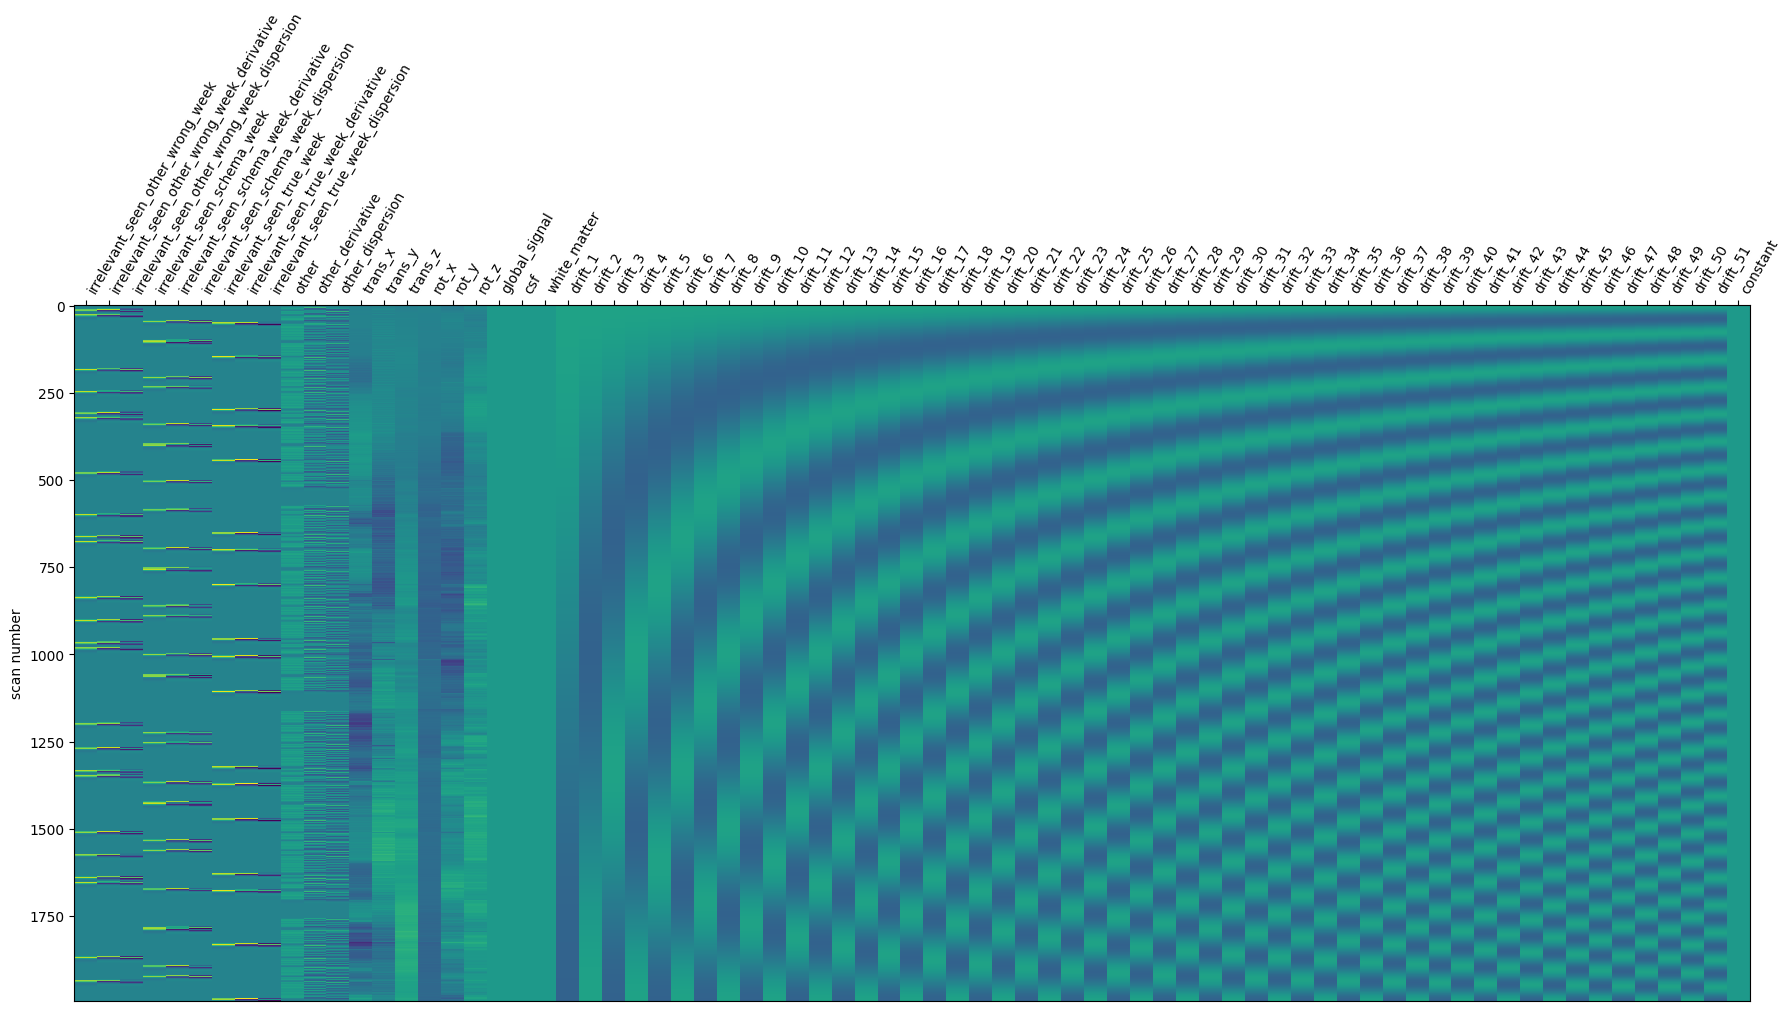

In [3]:
import json

with open(meta_file, "r") as f:
    metadata = json.load(f)

tr = metadata["RepetitionTime"]
n_scans = bold_img.shape[-1]
frame_times = np.arange(n_scans) * tr

confound_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z", "global_signal", "csf", "white_matter"]
confound_cols = [c for c in confound_cols if c in confounds.columns]
add_regs = confounds[confound_cols].fillna(0)

design_matrix = make_first_level_design_matrix(
    frame_times,
    glm_events,
    hrf_model="spm + derivative + dispersion",
    drift_model="cosine",
    high_pass=0.01,
    add_regs=add_regs,
    add_reg_names=add_regs.columns.tolist(),
)

print("Design matrix shape:", design_matrix.shape)
print([c for c in design_matrix.columns if "irrelevant_seen" in c])

plot_design_matrix(design_matrix)
plt.show()

In [4]:
from nilearn.glm.first_level import FirstLevelModel
from nilearn import datasets, image
import nibabel as nib

# Create a gray matter mask in MNI space, resampled to functional image
gm_mask = datasets.load_mni152_gm_mask(resolution=2, threshold=0.2, n_iter=2)
gm_mask_resampled = image.resample_to_img(
    gm_mask,
    bold_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

# Fit first-level model for this single session
fmri_glm = FirstLevelModel(
    mask_img=gm_mask_resampled,
    smoothing_fwhm=5,
    n_jobs=-1,
)

fmri_glm = fmri_glm.fit(
    bold_img,
    design_matrices=design_matrix,
)

print("GLM fitted.")

GLM fitted.


In [5]:
columns = design_matrix.columns.tolist()

contrast_vec = np.zeros(len(columns))

for i, col in enumerate(columns):
    if col == "irrelevant_seen_true_week":
        contrast_vec[i] = 1
    elif col == "irrelevant_seen_schema_week":
        contrast_vec[i] = -1

zmap_true_vs_schema = fmri_glm.compute_contrast(
    contrast_vec,
    output_type="z_score",
)

print("Contrast computed.")

Contrast computed.


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



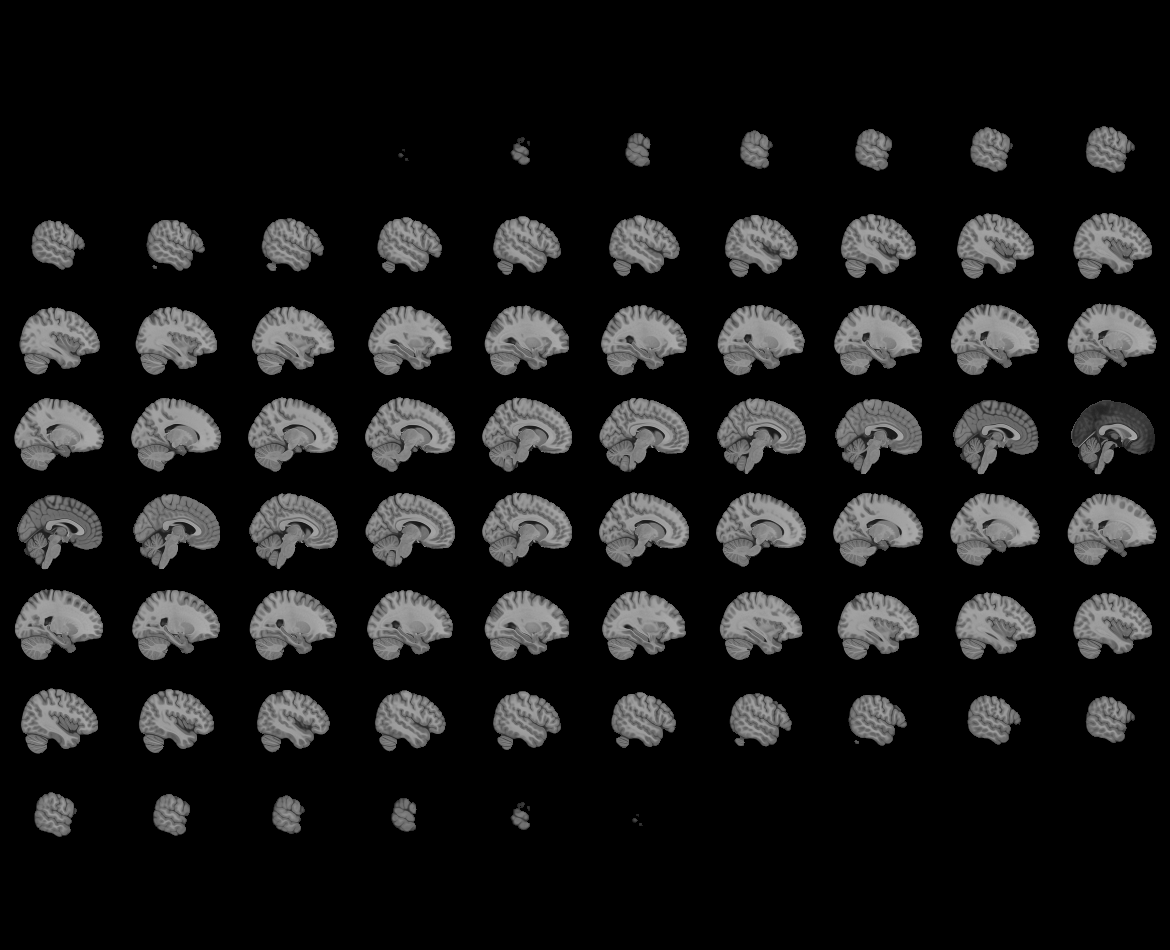
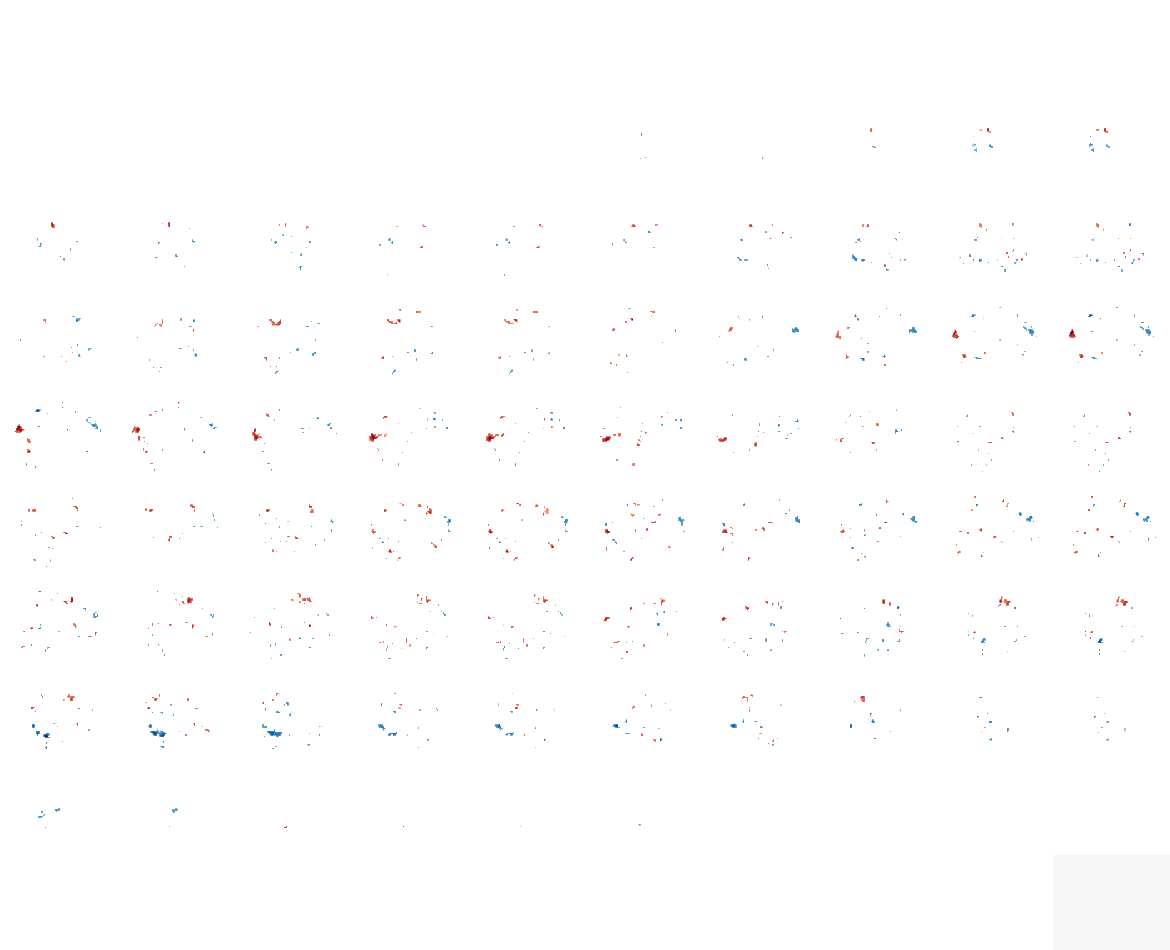

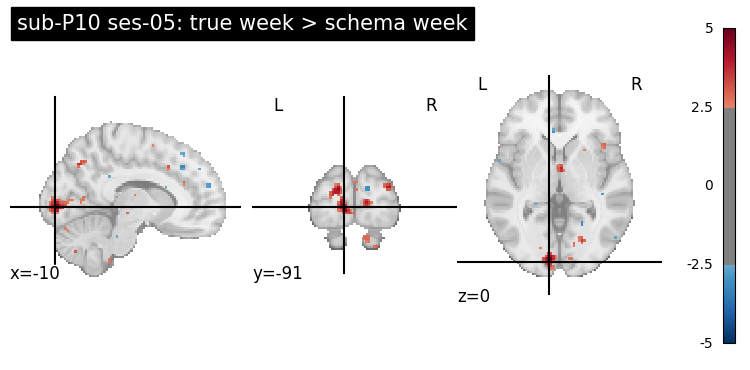

In [6]:
from nilearn import plotting

plotting.plot_stat_map(
    zmap_true_vs_schema,
    threshold=2.5,
    display_mode="ortho",
    title=f"{sub} {ses}: true week > schema week",
)

plotting.view_img(
    zmap_true_vs_schema,
    threshold=2.5,
    title=f"{sub} {ses}: true week > schema week",
)

# Combined pre/post GLM test for sub-P10

In [7]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import image, datasets, plotting
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

sub = "sub-P10"

In [8]:
def load_session(sub, ses):
    func_dir = Path("data/fmriprep_output") / sub / ses / "func"
    event_file = Path("data/preprocessed/relabeled_events") / f"{sub}_{ses}_task-viewing_run-01_events_memory_labels.tsv"
    
    bold_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
    confounds_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_desc-confounds_timeseries.tsv"
    meta_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.json"
    
    bold_img = nib.load(str(bold_file))
    events = pd.read_csv(event_file, sep="\t")
    confounds = pd.read_csv(confounds_file, sep="\t")
    
    with open(meta_file, "r") as f:
        metadata = json.load(f)
    
    return bold_img, events, confounds, metadata

pre_img, pre_events, pre_confounds, pre_meta = load_session(sub, "ses-01")
post_img, post_events, post_confounds, post_meta = load_session(sub, "ses-05")

print("Pre:", pre_img.shape, pre_events.shape, pre_confounds.shape)
print("Post:", post_img.shape, post_events.shape, post_confounds.shape)

print("\nPre labels:")
print(pre_events["trial_type_memory"].value_counts())

print("\nPost labels:")
print(post_events["trial_type_memory"].value_counts())

Pre: (62, 77, 66, 2026) (384, 9) (2026, 869)
Post: (62, 77, 66, 1994) (384, 9) (1994, 851)

Pre labels:
trial_type_memory
other                               312
irrelevant_seen_schema_week          30
irrelevant_seen_other_wrong_week     24
irrelevant_seen_true_week            18
Name: count, dtype: int64

Post labels:
trial_type_memory
other                               312
irrelevant_seen_schema_week          30
irrelevant_seen_other_wrong_week     24
irrelevant_seen_true_week            18
Name: count, dtype: int64


In [9]:
def events_for_glm(events, run_label):
    out = events[["onset", "duration", "trial_type_memory"]].copy()
    out = out.rename(columns={"trial_type_memory": "trial_type"})
    out["trial_type"] = run_label + "_" + out["trial_type"].astype(str)
    return out

tr = pre_meta["RepetitionTime"]
pre_duration = pre_img.shape[-1] * tr

pre_events_glm = events_for_glm(pre_events, "pre")
post_events_glm = events_for_glm(post_events, "post")

post_events_glm["onset"] += pre_duration

combined_events = pd.concat([pre_events_glm, post_events_glm], ignore_index=True)

print(combined_events["trial_type"].value_counts())
combined_events.head()

trial_type
pre_other                                312
post_other                               312
post_irrelevant_seen_schema_week          30
pre_irrelevant_seen_schema_week           30
post_irrelevant_seen_other_wrong_week     24
pre_irrelevant_seen_other_wrong_week      24
pre_irrelevant_seen_true_week             18
post_irrelevant_seen_true_week            18
Name: count, dtype: int64


,onset,duration,trial_type
0,4.634,3.017,pre_other
1,11.701,3.017,pre_irrelevant_seen_other_wrong_week
2,17.934,3.017,pre_other
3,24.534,3.017,pre_other
4,30.451,3.016,pre_irrelevant_seen_other_wrong_week


In [10]:
combined_img = image.concat_imgs([pre_img, post_img])

confound_cols = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z",
    "global_signal", "csf", "white_matter"
]

confound_cols = [c for c in confound_cols if c in pre_confounds.columns and c in post_confounds.columns]

pre_conf = pre_confounds[confound_cols].fillna(0).add_prefix("pre_")
post_conf = post_confounds[confound_cols].fillna(0).add_prefix("post_")

combined_confounds = pd.concat([pre_conf, post_conf], ignore_index=True).fillna(0)

print("Combined image:", combined_img.shape)
print("Combined confounds:", combined_confounds.shape)

Combined image: (62, 77, 66, 4020)
Combined confounds: (4020, 18)


In [11]:
n_scans = combined_img.shape[-1]
frame_times = np.arange(n_scans) * tr

design_matrix = make_first_level_design_matrix(
    frame_times,
    combined_events,
    hrf_model="spm + derivative + dispersion",
    drift_model="cosine",
    high_pass=0.01,
    add_regs=combined_confounds,
    add_reg_names=combined_confounds.columns.tolist(),
)

print("Design matrix:", design_matrix.shape)

memory_cols = [c for c in design_matrix.columns if "irrelevant_seen" in c]
memory_cols

Design matrix: (4020, 147)


['post_irrelevant_seen_other_wrong_week',
 'post_irrelevant_seen_other_wrong_week_derivative',
 'post_irrelevant_seen_other_wrong_week_dispersion',
 'post_irrelevant_seen_schema_week',
 'post_irrelevant_seen_schema_week_derivative',
 'post_irrelevant_seen_schema_week_dispersion',
 'post_irrelevant_seen_true_week',
 'post_irrelevant_seen_true_week_derivative',
 'post_irrelevant_seen_true_week_dispersion',
 'pre_irrelevant_seen_other_wrong_week',
 'pre_irrelevant_seen_other_wrong_week_derivative',
 'pre_irrelevant_seen_other_wrong_week_dispersion',
 'pre_irrelevant_seen_schema_week',
 'pre_irrelevant_seen_schema_week_derivative',
 'pre_irrelevant_seen_schema_week_dispersion',
 'pre_irrelevant_seen_true_week',
 'pre_irrelevant_seen_true_week_derivative',
 'pre_irrelevant_seen_true_week_dispersion']

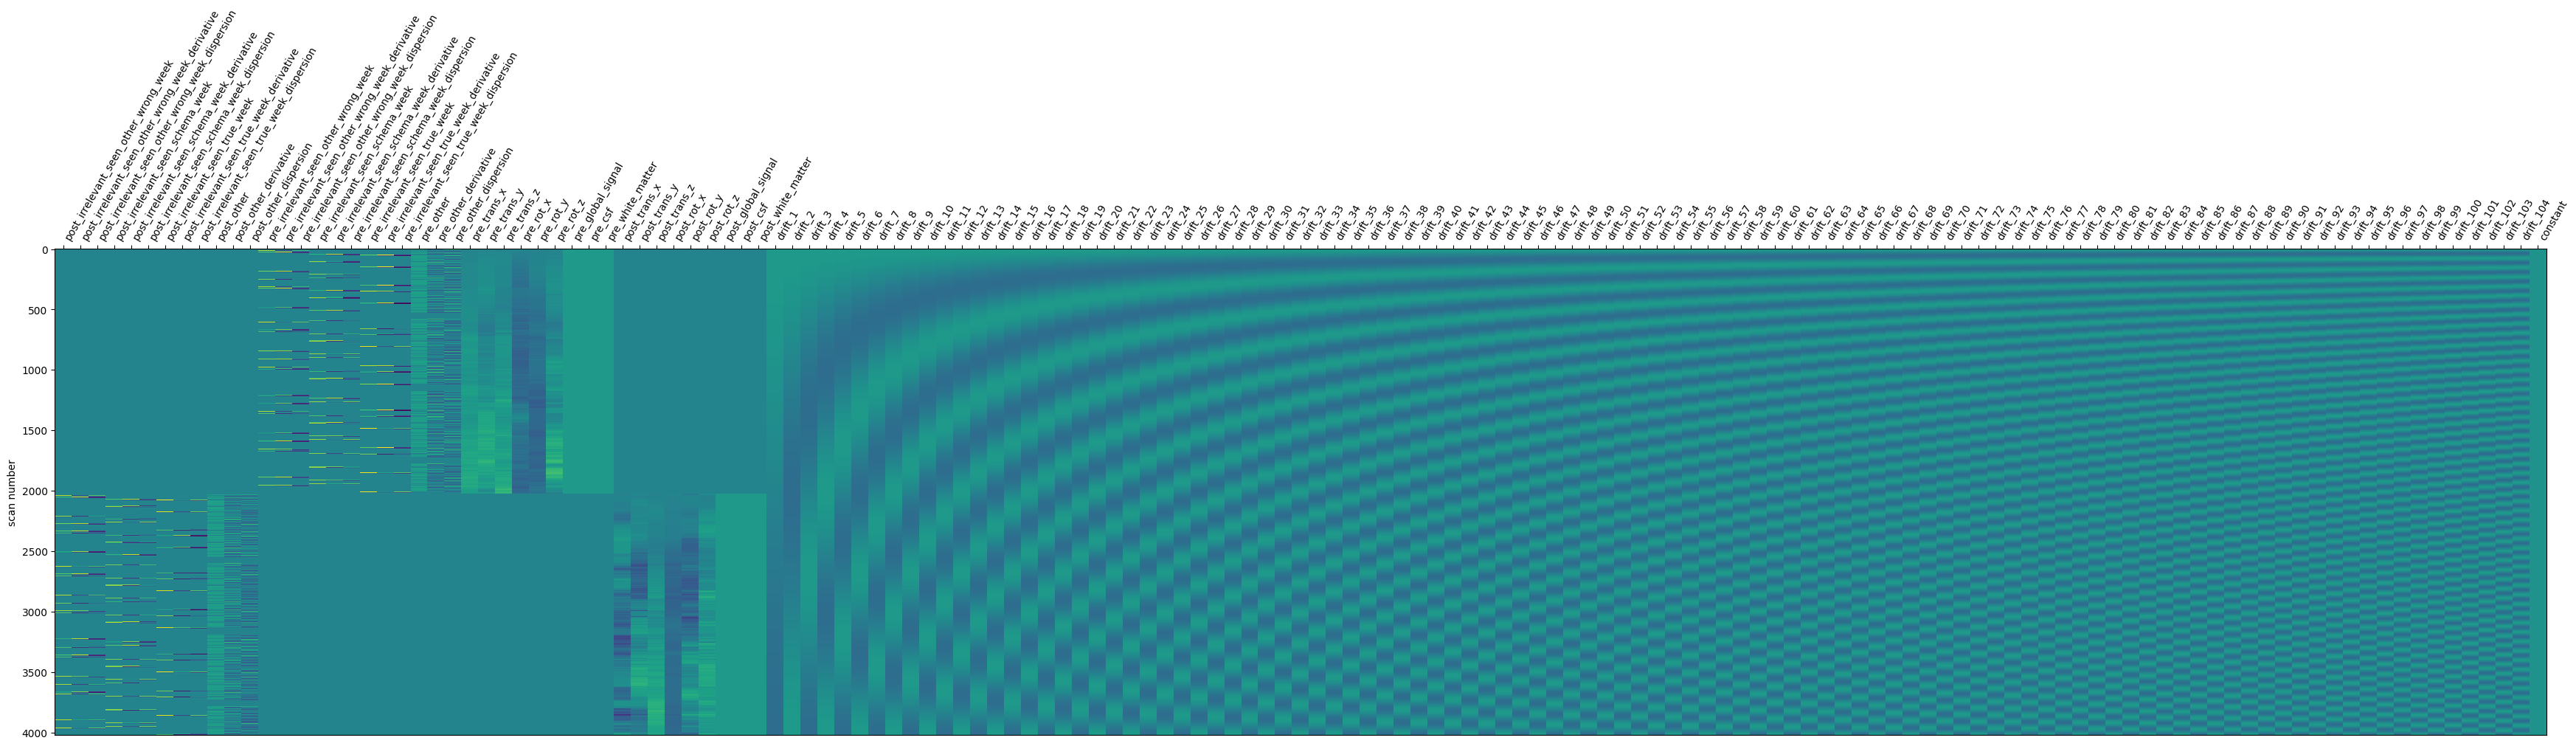

In [12]:
plot_design_matrix(design_matrix)
plt.show()

In [13]:
gm_mask = datasets.load_mni152_gm_mask(resolution=2, threshold=0.2, n_iter=2)
gm_mask_resampled = image.resample_to_img(
    gm_mask,
    combined_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

fmri_glm = FirstLevelModel(
    mask_img=gm_mask_resampled,
    smoothing_fwhm=5,
    n_jobs=-1,
)

fmri_glm = fmri_glm.fit(
    combined_img,
    design_matrices=design_matrix,
)

print("Combined GLM fitted.")

Combined GLM fitted.


In [14]:
columns = design_matrix.columns.tolist()

def contrast_from_weights(weights_dict):
    vec = np.zeros(len(columns))
    for name, weight in weights_dict.items():
        if name in columns:
            vec[columns.index(name)] = weight
        else:
            print("Missing column:", name)
    return vec

# Pre: true > schema
pre_true_vs_schema = contrast_from_weights({
    "pre_irrelevant_seen_true_week": 1,
    "pre_irrelevant_seen_schema_week": -1,
})

# Post: true > schema
post_true_vs_schema = contrast_from_weights({
    "post_irrelevant_seen_true_week": 1,
    "post_irrelevant_seen_schema_week": -1,
})

# Post-pre interaction
post_minus_pre_true_vs_schema = post_true_vs_schema - pre_true_vs_schema

z_pre = fmri_glm.compute_contrast(pre_true_vs_schema, output_type="z_score")
z_post = fmri_glm.compute_contrast(post_true_vs_schema, output_type="z_score")
z_post_pre = fmri_glm.compute_contrast(post_minus_pre_true_vs_schema, output_type="z_score")

print("Contrasts computed.")

Contrasts computed.


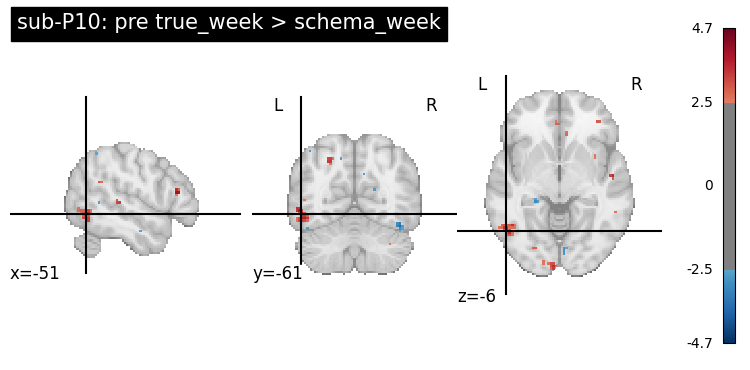

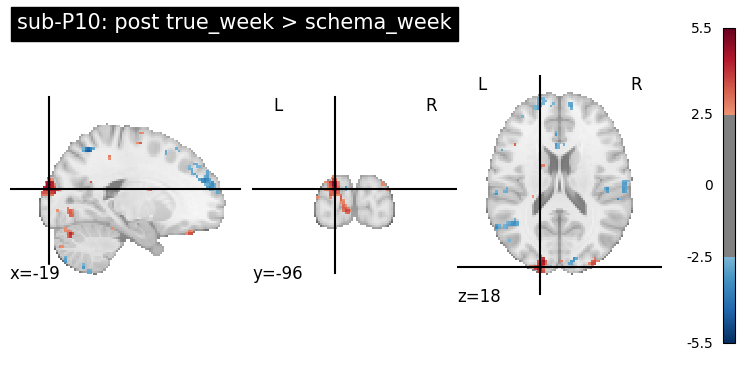

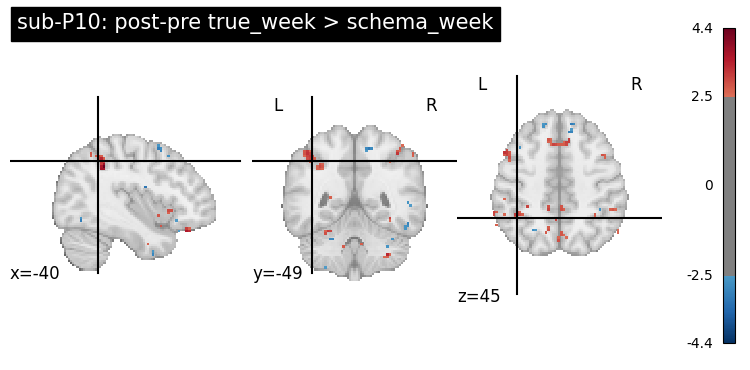

In [15]:
from nilearn import plotting

plotting.plot_stat_map(
    z_pre,
    threshold=2.5,
    display_mode="ortho",
    title=f"{sub}: pre true_week > schema_week",
)

plotting.plot_stat_map(
    z_post,
    threshold=2.5,
    display_mode="ortho",
    title=f"{sub}: post true_week > schema_week",
)

plotting.plot_stat_map(
    z_post_pre,
    threshold=2.5,
    display_mode="ortho",
    title=f"{sub}: post-pre true_week > schema_week",
)

## Group-level analysis of post-pre true week > schema week

In [16]:
from pathlib import Path
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting

contrast_paths = sorted(
    Path("data/processed/glm/irrelevant_seen_true_vs_schema")
    .glob("sub-P*/sub-P*_smooth_5.0_post-pre_true_vs_schema.nii.gz")
)

print("N contrast maps:", len(contrast_paths))
for p in contrast_paths:
    print(p)

N contrast maps: 20
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P10/sub-P10_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P12/sub-P12_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P13/sub-P13_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P14/sub-P14_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P15/sub-P15_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P18/sub-P18_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P19/sub-P19_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P20/sub-P20_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P21/sub-P21_smooth_5.0_post-pre_true_vs_schema.nii.gz
data/pro

In [17]:
second_level_input = [str(p) for p in contrast_paths]

design_matrix = pd.DataFrame(
    np.ones(len(second_level_input)),
    columns=["intercept"]
)

second_level_model = SecondLevelModel(smoothing_fwhm=None)
second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix
)

z_map_group = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score"
)

print("Group-level model fitted.")

Group-level model fitted.


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



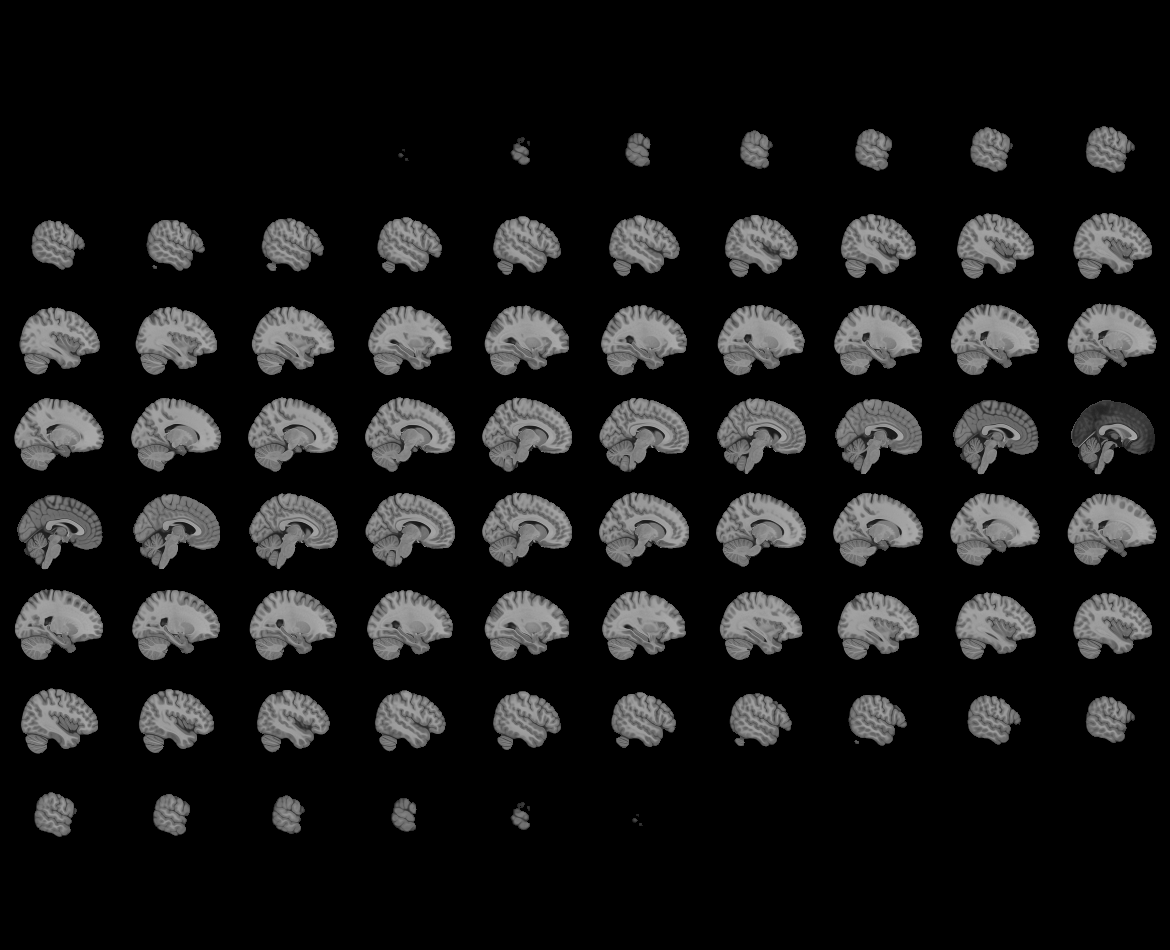
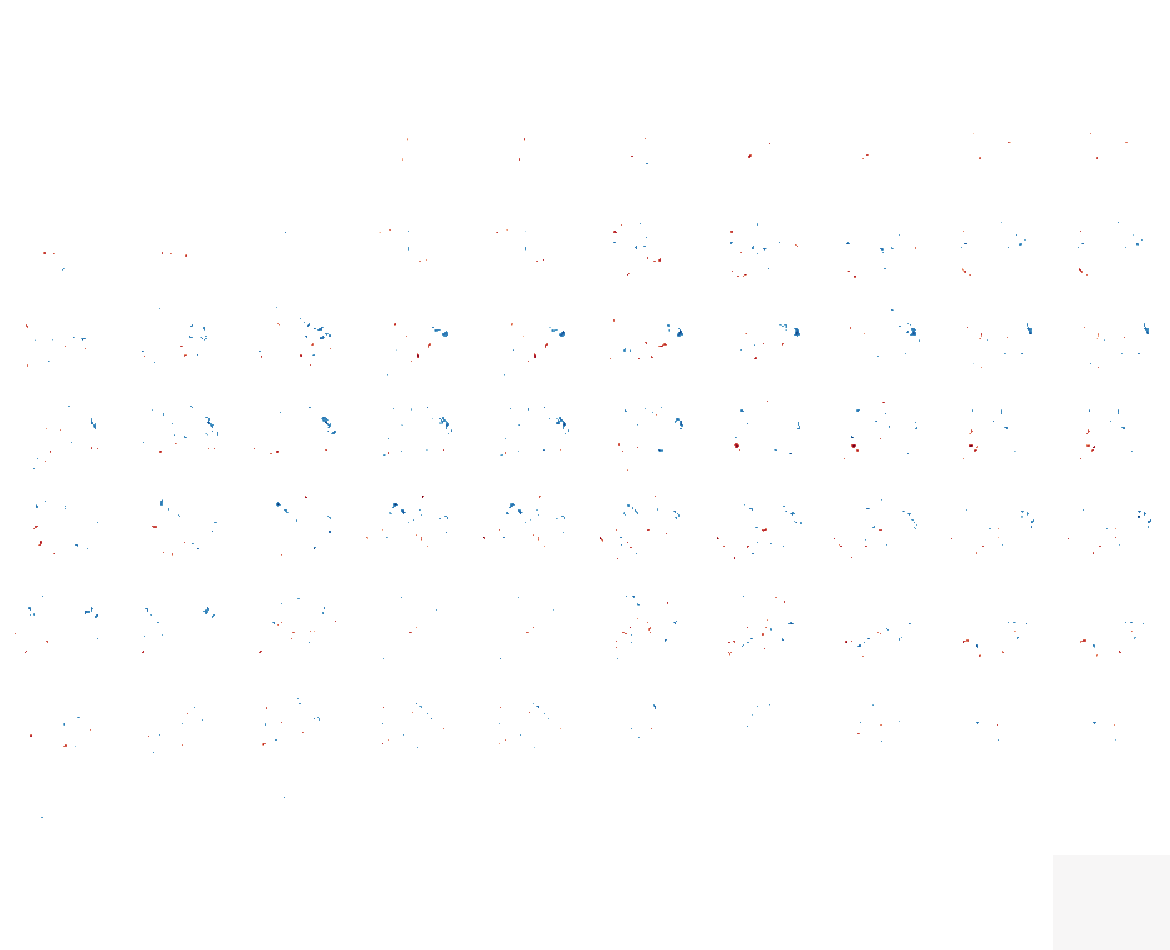

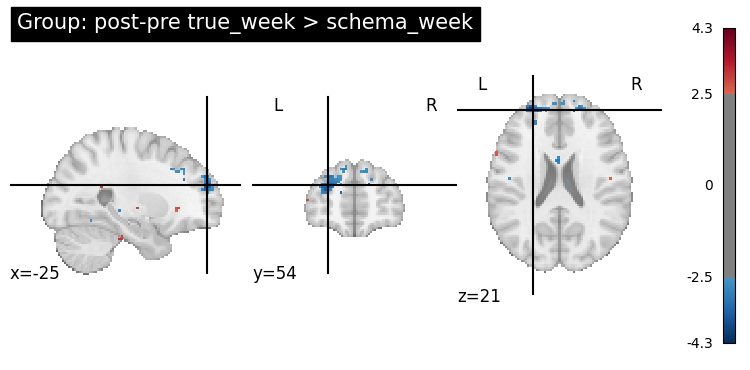

In [18]:
plotting.plot_stat_map(
    z_map_group,
    threshold=2.5,
    display_mode="ortho",
    title="Group: post-pre true_week > schema_week"
)

view = plotting.view_img(
    z_map_group,
    threshold=2.5,
    title="Group: post-pre true_week > schema_week"
)

view

In [19]:
out_dir = Path("data/processed/glm/irrelevant_seen_true_vs_schema/group_level")
out_dir.mkdir(parents=True, exist_ok=True)

z_map_path = out_dir / "group_post-pre_true_vs_schema_zmap.nii.gz"
z_map_group.to_filename(z_map_path)

print("Saved:", z_map_path)

Saved: data/processed/glm/irrelevant_seen_true_vs_schema/group_level/group_post-pre_true_vs_schema_zmap.nii.gz


In [20]:
from nilearn.reporting import get_clusters_table

clusters = get_clusters_table(
    z_map_group,
    stat_threshold=2.5,
    cluster_threshold=5
)

clusters

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-3.5,-64.5,-15.5,4.272540,453
1,2,11.5,-104.5,-10.5,4.148173,234
2,3,36.5,-79.5,-28.0,3.913032,390
3,3a,41.5,-72.0,-25.5,3.471614,
4,4,-31.0,0.5,-25.5,3.784289,265
5,5,9.0,8.0,74.5,3.769568,93
6,6,-48.5,15.5,-23.0,3.598140,93
7,7,-28.5,18.0,-5.5,3.583098,328
8,8,-66.0,-39.5,-5.5,3.550366,171
9,9,1.5,-54.5,-18.0,3.523539,296


In [21]:
from nilearn import datasets
from nilearn.reporting import get_clusters_table
import pandas as pd
import numpy as np

clusters = get_clusters_table(
    z_map_group,
    stat_threshold=2.5,
    cluster_threshold=5
)

atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_img = atlas.maps
labels = atlas.labels

from nilearn.image import coord_transform

def label_peak(row):
    x, y, z = row["X"], row["Y"], row["Z"]
    i, j, k = np.round(
        coord_transform(x, y, z, np.linalg.inv(atlas_img.affine))
    ).astype(int)

    data = atlas_img.get_fdata()
    if (
        i < 0 or j < 0 or k < 0 or
        i >= data.shape[0] or j >= data.shape[1] or k >= data.shape[2]
    ):
        return "out_of_bounds"

    idx = int(data[i, j, k])
    if idx < len(labels):
        return labels[idx]
    return "unknown"

clusters["HarvardOxford_label"] = clusters.apply(label_peak, axis=1)
clusters

[fetch_atlas_harvard_oxford] Added README.md to /home/kroczak/nilearn_data
[fetch_atlas_harvard_oxford] Dataset created in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz ...
Downloaded 11141120 of 25716861 bytes (43.3%%,    1.3s remaining)
[fetch_atlas_harvard_oxford]  ...done. (3 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from /home/kroczak/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...
[fetch_atlas_harvard_oxford] .. done.



,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),HarvardOxford_label
0,1,-3.5,-64.5,-15.5,4.272540,453,Background
1,2,11.5,-104.5,-10.5,4.148173,234,Background
2,3,36.5,-79.5,-28.0,3.913032,390,Background
3,3a,41.5,-72.0,-25.5,3.471614,,Background
4,4,-31.0,0.5,-25.5,3.784289,265,Background
5,5,9.0,8.0,74.5,3.769568,93,Superior Frontal Gyrus
6,6,-48.5,15.5,-23.0,3.598140,93,Temporal Pole
7,7,-28.5,18.0,-5.5,3.583098,328,Insular Cortex
8,8,-66.0,-39.5,-5.5,3.550366,171,"Middle Temporal Gyrus, posterior division"
9,9,1.5,-54.5,-18.0,3.523539,296,Background


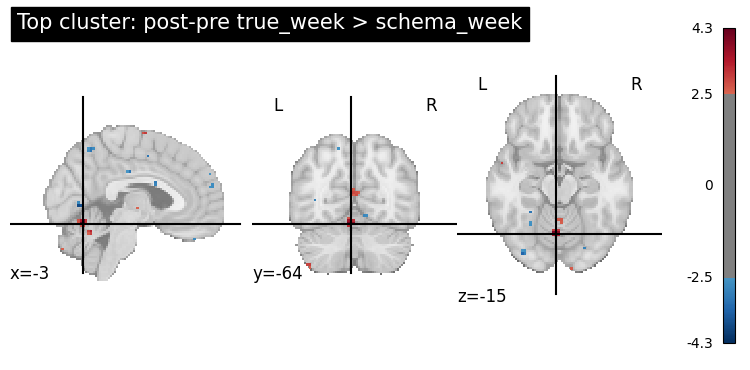

In [22]:
plotting.plot_stat_map(
    z_map_group,
    threshold=2.5,
    display_mode="ortho",
    cut_coords=(-3.5, -64.5, -15.5),
    title="Top cluster: post-pre true_week > schema_week"
)

## ROI analysis: hippocampus, amygdala, parahippocampal gyrus

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import datasets, image, plotting
from scipy.stats import ttest_1samp, wilcoxon

contrast_paths = sorted(
    Path("data/processed/glm/irrelevant_seen_true_vs_schema")
    .glob("sub-P*/sub-P*_smooth_5.0_post-pre_true_vs_schema.nii.gz")
)

subjects = [p.parent.name for p in contrast_paths]

print("N maps:", len(contrast_paths))
print(subjects)

N maps: 20
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P18', 'sub-P19', 'sub-P20', 'sub-P21', 'sub-P23', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P41', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P49', 'sub-P50']


In [24]:
subcort = datasets.fetch_atlas_harvard_oxford(
    "sub-maxprob-thr25-2mm"
)

subcort_img = subcort.maps
subcort_labels = subcort.labels

for i, label in enumerate(subcort_labels):
    if "Hippocampus" in label or "Amygdala" in label:
        print(i, label)

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
9 Left Hippocampus
10 Left Amygdala
19 Right Hippocampus
20 Right Amygdala


In [26]:
import nibabel as nib
import numpy as np
from nilearn import image

subcort_data = subcort_img.get_fdata()

hippocampus_indices = [
    i for i, label in enumerate(subcort_labels)
    if "Hippocampus" in label
]

amygdala_indices = [
    i for i, label in enumerate(subcort_labels)
    if "Amygdala" in label
]

hippocampus_data = np.isin(subcort_data, hippocampus_indices).astype("uint8")
amygdala_data = np.isin(subcort_data, amygdala_indices).astype("uint8")

hippocampus_mask = nib.Nifti1Image(
    hippocampus_data,
    subcort_img.affine,
    subcort_img.header
)

amygdala_mask = nib.Nifti1Image(
    amygdala_data,
    subcort_img.affine,
    subcort_img.header
)

print("Hippocampus labels:", [subcort_labels[i] for i in hippocampus_indices])
print("Amygdala labels:", [subcort_labels[i] for i in amygdala_indices])
print("Hippocampus voxels:", int(hippocampus_data.sum()))
print("Amygdala voxels:", int(amygdala_data.sum()))

Hippocampus labels: ['Left Hippocampus', 'Right Hippocampus']
Amygdala labels: ['Left Amygdala', 'Right Amygdala']
Hippocampus voxels: 1391
Amygdala voxels: 672


In [27]:
# Fetch cortical Harvard-Oxford atlas for parahippocampal gyrus
cort = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

cort_img = cort.maps
cort_labels = cort.labels

# Print parahippocampal labels
for i, label in enumerate(cort_labels):
    if "Parahippocampal" in label:
        print(i, label)

parahipp_indices = [
    i for i, label in enumerate(cort_labels)
    if "Parahippocampal" in label
]

cort_data = cort_img.get_fdata()
parahipp_data = np.isin(cort_data, parahipp_indices).astype("uint8")

parahipp_mask = nib.Nifti1Image(
    parahipp_data,
    cort_img.affine,
    cort_img.header
)

print("Parahippocampal labels:", [cort_labels[i] for i in parahipp_indices])
print("Parahippocampal voxels:", int(parahipp_data.sum()))

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
34 Parahippocampal Gyrus, anterior division
35 Parahippocampal Gyrus, posterior division
Parahippocampal labels: ['Parahippocampal Gyrus, anterior division', 'Parahippocampal Gyrus, posterior division']
Parahippocampal voxels: 1958


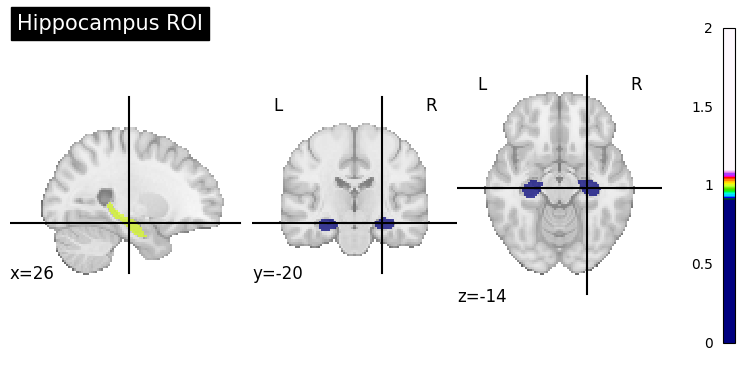

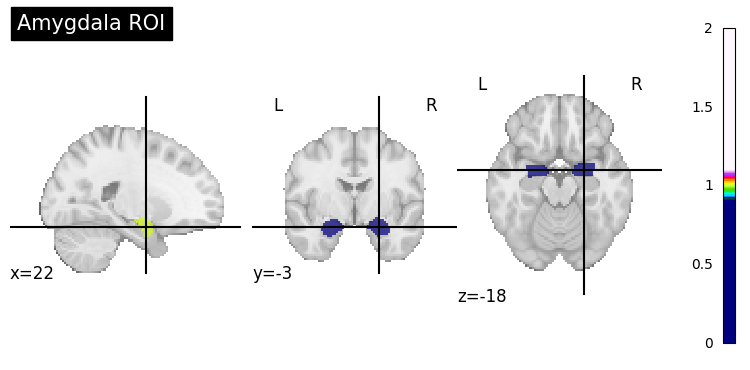

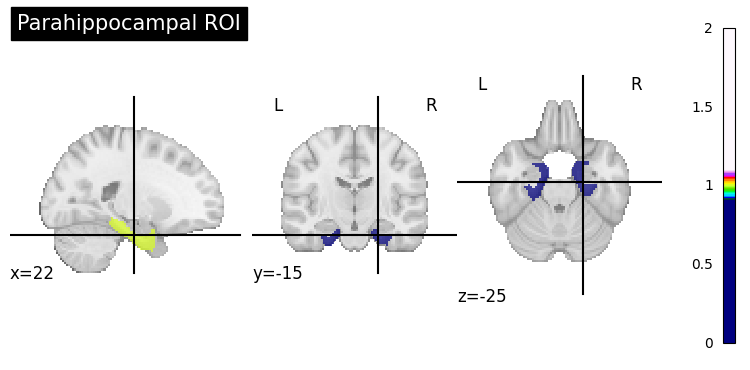

In [28]:
plotting.plot_roi(
    hippocampus_mask,
    title="Hippocampus ROI",
    display_mode="ortho"
)

plotting.plot_roi(
    amygdala_mask,
    title="Amygdala ROI",
    display_mode="ortho"
)

plotting.plot_roi(
    parahipp_mask,
    title="Parahippocampal ROI",
    display_mode="ortho"
)

In [29]:
def extract_mean_in_mask(img_path, mask_img):
    img = nib.load(str(img_path))
    
    mask_resampled = image.resample_to_img(
        mask_img,
        img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    data = img.get_fdata()
    mask = mask_resampled.get_fdata().astype(bool)
    
    values = data[mask]
    values = values[np.isfinite(values)]
    
    return np.mean(values)

roi_rows = []

for path in contrast_paths:
    sub = path.parent.name
    
    roi_rows.append({
        "sub": sub,
        "hippocampus": extract_mean_in_mask(path, hippocampus_mask),
        "amygdala": extract_mean_in_mask(path, amygdala_mask),
        "parahippocampal": extract_mean_in_mask(path, parahipp_mask),
    })

roi_df = pd.DataFrame(roi_rows)

display(roi_df)

,sub,hippocampus,amygdala,parahippocampal
0,sub-P10,-0.443982,-0.592448,-0.121701
1,sub-P12,-0.894636,-1.108369,-0.465652
2,sub-P13,-0.122605,-0.468218,-0.245465
3,sub-P14,-0.807221,-1.001687,-0.464275
4,sub-P15,-0.255118,-0.736352,-0.003699
5,sub-P18,0.033600,0.258930,-0.060475
6,sub-P19,-0.093714,-0.391846,-0.127781
7,sub-P20,0.698605,0.360056,0.119922
8,sub-P21,0.421602,0.048148,0.260584
9,sub-P23,-1.046417,-1.147339,-0.875552


In [30]:
from scipy.stats import ttest_1samp, wilcoxon

for roi in ["hippocampus", "amygdala", "parahippocampal"]:
    values = roi_df[roi].dropna()
    
    print("\n" + "="*50)
    print(roi)
    print("="*50)
    print(values.describe())
    print("Mean:", values.mean())
    print("One-sample t-test vs 0:", ttest_1samp(values, 0))
    
    try:
        print("Wilcoxon vs 0:", wilcoxon(values))
    except Exception as e:
        print("Wilcoxon failed:", e)


hippocampus
count    20.000000
mean      0.002782
std       0.509557
min      -1.046417
25%      -0.264750
50%       0.020197
75%       0.429516
max       0.698605
Name: hippocampus, dtype: float64
Mean: 0.002782455417220561
One-sample t-test vs 0: TtestResult(statistic=np.float64(0.024420288270334756), pvalue=np.float64(0.9807720208994476), df=np.int64(19))
Wilcoxon vs 0: WilcoxonResult(statistic=np.float64(95.0), pvalue=np.float64(0.7285060882568359))

amygdala
count    20.000000
mean     -0.146130
std       0.674258
min      -1.147339
25%      -0.607903
50%      -0.225724
75%       0.284212
max       1.255551
Name: amygdala, dtype: float64
Mean: -0.1461304203494091
One-sample t-test vs 0: TtestResult(statistic=np.float64(-0.9692354087992747), pvalue=np.float64(0.34460503874559145), df=np.int64(19))
Wilcoxon vs 0: WilcoxonResult(statistic=np.float64(77.0), pvalue=np.float64(0.3117942810058594))

parahippocampal
count    20.000000
mean     -0.007843
std       0.332551
min      -0.875

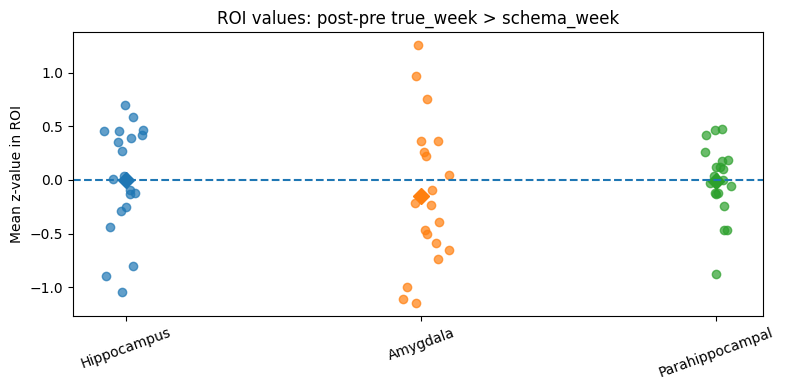

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))

for i, roi in enumerate(["hippocampus", "amygdala", "parahippocampal"]):
    vals = roi_df[roi].values
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    ax.scatter(x, vals, alpha=0.7)
    ax.plot(i, vals.mean(), marker="D", markersize=8)

ax.axhline(0, linestyle="--")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Hippocampus", "Amygdala", "Parahippocampal"], rotation=20)
ax.set_ylabel("Mean z-value in ROI")
ax.set_title("ROI values: post-pre true_week > schema_week")

plt.tight_layout()
plt.show()

In [32]:
out_dir = Path("data/processed/glm/irrelevant_seen_true_vs_schema/group_level")
out_dir.mkdir(parents=True, exist_ok=True)

roi_df.to_csv(out_dir / "roi_values_post-pre_true_vs_schema.csv", index=False)
print("Saved ROI values.")

Saved ROI values.


#post 

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting

post_paths = sorted(
    Path("data/processed/glm/irrelevant_seen_true_vs_schema")
    .glob("sub-P*/sub-P*_smooth_5.0_post_true_vs_schema.nii.gz")
)

print("N post maps:", len(post_paths))
for p in post_paths:
    print(p)

N post maps: 20
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P10/sub-P10_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P12/sub-P12_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P13/sub-P13_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P14/sub-P14_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P15/sub-P15_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P18/sub-P18_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P19/sub-P19_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P20/sub-P20_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schema/sub-P21/sub-P21_smooth_5.0_post_true_vs_schema.nii.gz
data/processed/glm/irrelevant_seen_true_vs_schem

In [34]:
second_level_input = [str(p) for p in post_paths]

design_matrix_post = pd.DataFrame(
    np.ones(len(second_level_input)),
    columns=["intercept"]
)

second_level_model_post = SecondLevelModel(smoothing_fwhm=None)
second_level_model_post = second_level_model_post.fit(
    second_level_input,
    design_matrix=design_matrix_post
)

z_map_post_group = second_level_model_post.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score"
)

print("Group-level post model fitted.")

Group-level post model fitted.


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



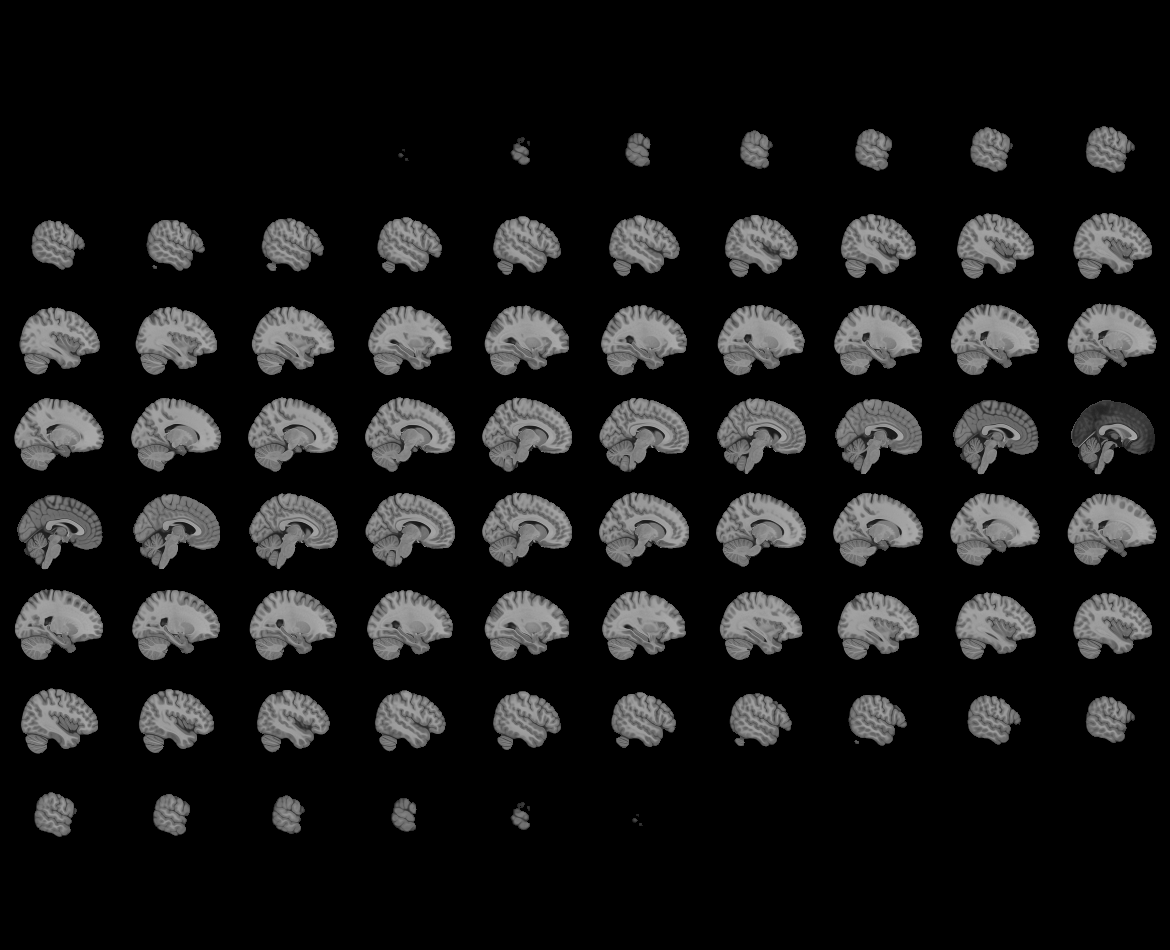
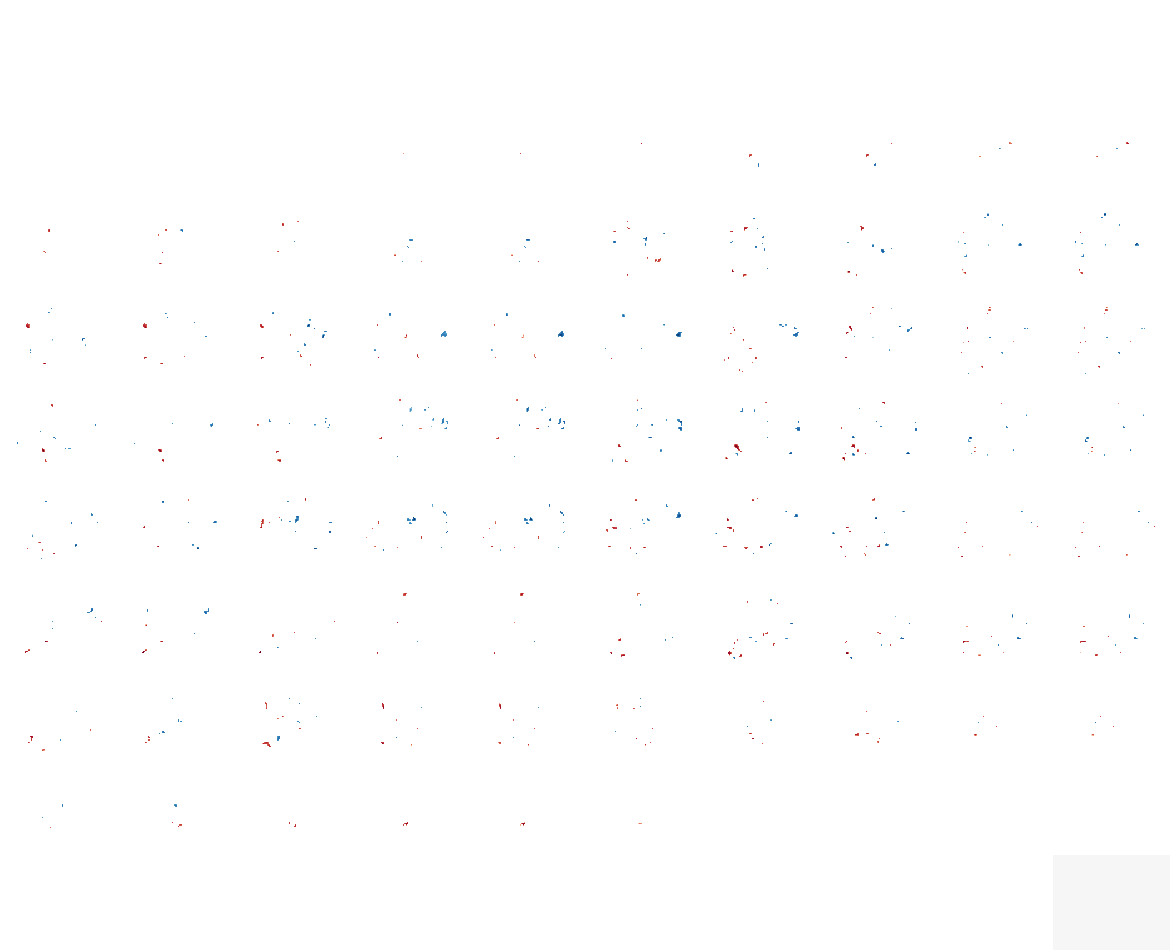

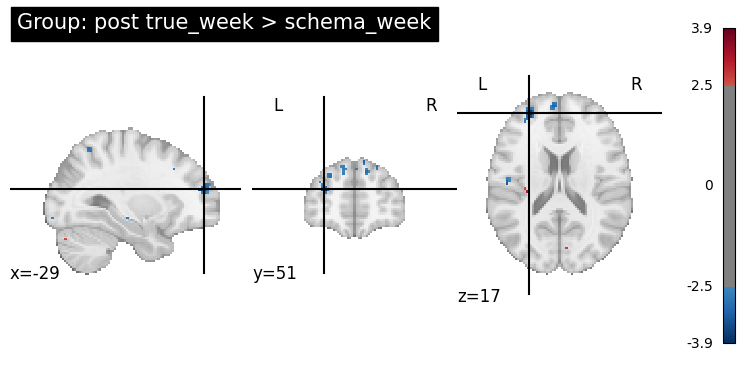

In [35]:
plotting.plot_stat_map(
    z_map_post_group,
    threshold=2.5,
    display_mode="ortho",
    title="Group: post true_week > schema_week"
)

view_post = plotting.view_img(
    z_map_post_group,
    threshold=2.5,
    title="Group: post true_week > schema_week"
)

view_post

In [36]:
from nilearn.reporting import get_clusters_table

clusters_post = get_clusters_table(
    z_map_post_group,
    stat_threshold=2.5,
    cluster_threshold=5
)

clusters_post

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-6.0,-67.0,-15.5,3.889088,359
1,2,49.0,-69.5,32.0,3.879266,281
2,3,21.5,-44.5,-25.5,3.796110,93
3,4,24.0,-82.0,-48.0,3.730343,500
4,4a,36.5,-79.5,-48.0,3.461841,
5,4b,19.0,-82.0,-45.5,3.162467,
6,5,-46.0,-74.5,-45.5,3.719379,156
7,6,-18.5,-49.5,-23.0,3.660778,203
8,7,69.0,-24.5,-10.5,3.558804,171
9,8,41.5,-72.0,-25.5,3.454550,296


In [37]:
out_dir = Path("data/processed/glm/irrelevant_seen_true_vs_schema/group_level")
out_dir.mkdir(parents=True, exist_ok=True)

z_map_post_path = out_dir / "group_post_true_vs_schema_zmap.nii.gz"
z_map_post_group.to_filename(z_map_post_path)

print("Saved:", z_map_post_path)

Saved: data/processed/glm/irrelevant_seen_true_vs_schema/group_level/group_post_true_vs_schema_zmap.nii.gz


In [38]:
post_roi_rows = []

for path in post_paths:
    sub = path.parent.name
    
    post_roi_rows.append({
        "sub": sub,
        "hippocampus": extract_mean_in_mask(path, hippocampus_mask),
        "amygdala": extract_mean_in_mask(path, amygdala_mask),
        "parahippocampal": extract_mean_in_mask(path, parahipp_mask),
    })

post_roi_df = pd.DataFrame(post_roi_rows)

display(post_roi_df)

for roi in ["hippocampus", "amygdala", "parahippocampal"]:
    values = post_roi_df[roi].dropna()
    
    print("\n" + "="*50)
    print(roi)
    print("="*50)
    print(values.describe())
    print("Mean:", values.mean())
    print("One-sample t-test vs 0:", ttest_1samp(values, 0))
    
    try:
        print("Wilcoxon vs 0:", wilcoxon(values))
    except Exception as e:
        print("Wilcoxon failed:", e)

,sub,hippocampus,amygdala,parahippocampal
0,sub-P10,-0.211943,-0.836634,-0.021691
1,sub-P12,-0.163277,-0.327522,-0.036114
2,sub-P13,-0.144619,-0.712559,-0.054078
3,sub-P14,-0.979066,-1.492566,-0.480625
4,sub-P15,-0.594307,-1.630560,-0.221575
5,sub-P18,-0.199825,0.536448,-0.119477
6,sub-P19,-0.491816,-1.097370,-0.293267
7,sub-P20,0.792114,0.559241,0.097224
8,sub-P21,0.348505,0.363278,0.082172
9,sub-P23,-1.433808,-1.399792,-0.714195



hippocampus
count    20.000000
mean     -0.014977
std       0.655177
min      -1.433808
25%      -0.281911
50%      -0.067094
75%       0.382258
max       1.281571
Name: hippocampus, dtype: float64
Mean: -0.014976579199502283
One-sample t-test vs 0: TtestResult(statistic=np.float64(-0.10222778721647267), pvalue=np.float64(0.9196470697572539), df=np.int64(19))
Wilcoxon vs 0: WilcoxonResult(statistic=np.float64(102.0), pvalue=np.float64(0.9272785186767578))

amygdala
count    20.000000
mean     -0.272387
std       0.826807
min      -1.630560
25%      -0.896394
50%      -0.362813
75%       0.478663
max       0.948135
Name: amygdala, dtype: float64
Mean: -0.2723871218293604
One-sample t-test vs 0: TtestResult(statistic=np.float64(-1.4733216113789105), pvalue=np.float64(0.15703889925304507), df=np.int64(19))
Wilcoxon vs 0: WilcoxonResult(statistic=np.float64(69.0), pvalue=np.float64(0.1893482208251953))

parahippocampal
count    20.000000
mean     -0.009845
std       0.370716
min      -0.7